In [1]:
# "CUSTOMER PURCHASE ANALYSIS"

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print("All libraries imported successfully!")


All libraries imported successfully!


In [3]:
# Day 1 – Data Loading & Initial Exploration

In [4]:
#STEP 1 : Load Dataset
#I load the Online Retail dataset to begin analysis.


In [5]:
df = pd.read_excel(r"C:\Users\evare\Documents\customer-purchase-analysis\data\Sales_Data.xlsx")

In [6]:
print(df)

       InvoiceNo StockCode                          Description  Quantity  \
0         536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1         536365     71053                  WHITE METAL LANTERN         6   
2         536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3         536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4         536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
...          ...       ...                                  ...       ...   
541904    581587     22613          PACK OF 20 SPACEBOY NAPKINS        12   
541905    581587     22899         CHILDREN'S APRON DOLLY GIRL          6   
541906    581587     23254        CHILDRENS CUTLERY DOLLY GIRL          4   
541907    581587     23255      CHILDRENS CUTLERY CIRCUS PARADE         4   
541908    581587     22138        BAKING SET 9 PIECE RETROSPOT          3   

               InvoiceDate  UnitPrice  CustomerID         Country  
0      

In [7]:
#STEP 2 : Preview Data
df.head(10)   # previewing the first few rows using 'head()'

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom


In [8]:
# STEP 3 : Data Overview
df.info() #Using 'df.info()', I run 'info()' to check column types and missing values.

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [9]:
#STEP 4 : Summary Statistics
df.describe() # I use 'describe()' to see basic statistics for numerical columns.


,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [10]:
#STEP 5 : Missing Values Check
df.isnull().sum() # I run 'isnull().sum()' to identify columns with missing data.

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [11]:
# Day 2 – Data Cleaning & Preparation

In [12]:
# STEP 1 :  Understanding the Size of the Dataset

In [13]:
df.shape

(541909, 8)

In [14]:
# STEP 2 : Removing Rows with Missing Customer Information

In [15]:
df = df.dropna(subset=['CustomerID', 'Description'])
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


In [16]:
# STEP 3 : Check Negative Quantity

In [17]:
negative_quantity = df[df['Quantity'] < 0]
negative_quantity.shape

(8905, 8)

In [18]:
# STEP 4: Remove Negative Quantity

In [19]:
df = df[df['Quantity'] > 0]
df.shape

(397924, 8)

In [20]:
# STEP 5: Checking for Zero UnitPrice

In [21]:
zero_price = (df['UnitPrice'] == 0).sum()
print(zero_price)

40


In [22]:
# STEP 6 : Removing Transactions with Zero UnitPrice

In [23]:
df = df[df['UnitPrice'] > 0]
df.shape

(397884, 8)

In [24]:
# STEP 7: Checking for Duplicate Rows

In [25]:
duplicated_rows = df.duplicated().sum()
print(duplicated_rows)

5192


In [26]:
# STEP 8: Removing Duplicate Rows

In [27]:
df = df.drop_duplicates()
df.shape

(392692, 8)

In [28]:
# STEP 9: Validating InvoiceDate Datatype

In [29]:
invoice_data_type = df['InvoiceDate'].dtype
print(invoice_data_type)

datetime64[us]


In [30]:
# STEP 10: Extracting Time-Based Features from InvoiceDate

In [31]:
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['Weekday'] = df['InvoiceDate'].dt.day_name()
df['Hour'] = df['InvoiceDate'].dt.hour

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Year,Month,Weekday,Hour
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,2010,12,Wednesday,8
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010,12,Wednesday,8
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,2010,12,Wednesday,8
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010,12,Wednesday,8
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010,12,Wednesday,8


In [32]:
# STEP 11: Create TotalPrice Column (Total Price = Quantity * Unit Price)

In [33]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Year,Month,Weekday,Hour,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,2010,12,Wednesday,8,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010,12,Wednesday,8,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,2010,12,Wednesday,8,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010,12,Wednesday,8,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,2010,12,Wednesday,8,20.34


In [34]:
df.info

<bound method DataFrame.info of        InvoiceNo StockCode                          Description  Quantity  \
0         536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1         536365     71053                  WHITE METAL LANTERN         6   
2         536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3         536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4         536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
...          ...       ...                                  ...       ...   
541904    581587     22613          PACK OF 20 SPACEBOY NAPKINS        12   
541905    581587     22899         CHILDREN'S APRON DOLLY GIRL          6   
541906    581587     23254        CHILDRENS CUTLERY DOLLY GIRL          4   
541907    581587     23255      CHILDRENS CUTLERY CIRCUS PARADE         4   
541908    581587     22138        BAKING SET 9 PIECE RETROSPOT          3   

               InvoiceDate  UnitPrice  Cust

In [35]:
# Final Quick Check

In [36]:
df.dtypes

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
Year                    int32
Month                   int32
Weekday                   str
Hour                    int32
TotalPrice            float64
dtype: object

In [37]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
Year           0
Month          0
Weekday        0
Hour           0
TotalPrice     0
dtype: int64

In [38]:
(df['Quantity'] < 0).sum()

np.int64(0)

In [39]:
(df['UnitPrice'] < 0).sum()

np.int64(0)

In [40]:
df['TotalPrice'].sum()

np.float64(8887208.894000001)

In [41]:
df['CustomerID'].nunique()

4338

In [43]:
df['Country'].nunique()

37

In [ ]:
# Day 3 – Customer Purchase Analysis

In [ ]:
# STEP 1 : Top Products by Quantity

In [44]:
# Top 10 products by quantity sold
top_products_qty = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)
top_products_qty

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54319
JUMBO BAG RED RETROSPOT               46078
WHITE HANGING HEART T-LIGHT HOLDER    36706
ASSORTED COLOUR BIRD ORNAMENT         35263
PACK OF 72 RETROSPOT CAKE CASES       33670
POPCORN HOLDER                        30919
RABBIT NIGHT LIGHT                    27153
MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64

<function matplotlib.pyplot.show(close=None, block=None)>

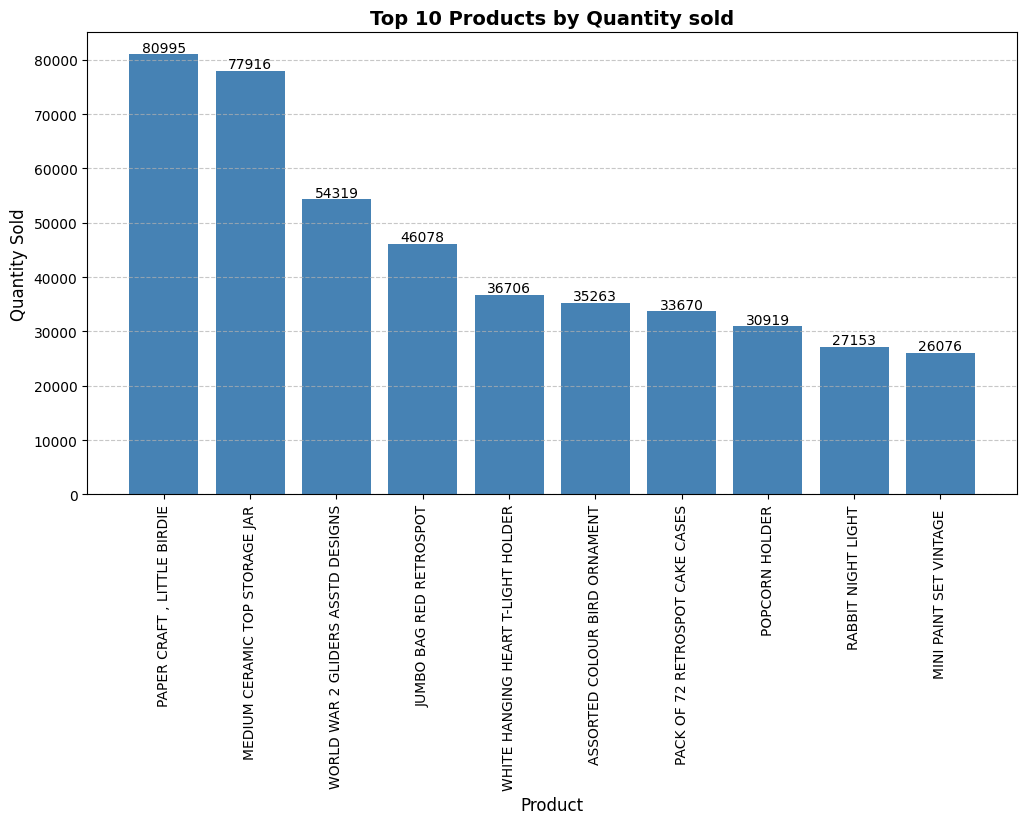

In [ ]:
# Visualization
plt.figure(figsize=(12,6))
plt.bar(top_products_qty.index,top_products_qty.values, color = 'steelblue')
plt.xticks(rotation = 90)
plt.title('Top 10 Products by Quantity sold', fontsize=14, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels on top of bars
for i, v in enumerate(top_products_qty.values):
    plt.text(i, v + 500, str(v), ha='center', fontsize=10)
    
plt.xlabel('Product', fontsize = 12)
plt.ylabel('Quantity Sold', fontsize = 12) 
plt.show


In [ ]:
# STEP 2 : Top Products by Revenue

In [77]:
# Top 10 products by revenue
top_products_rev = df.groupby('Description')['TotalPrice'].sum().sort_values(ascending= False).head(10)
top_products_rev

Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              142264.75
WHITE HANGING HEART T-LIGHT HOLDER    100392.10
JUMBO BAG RED RETROSPOT                85040.54
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
POSTAGE                                77803.96
PARTY BUNTING                          68785.23
ASSORTED COLOUR BIRD ORNAMENT          56413.03
Manual                                 53419.93
RABBIT NIGHT LIGHT                     51251.24
Name: TotalPrice, dtype: float64

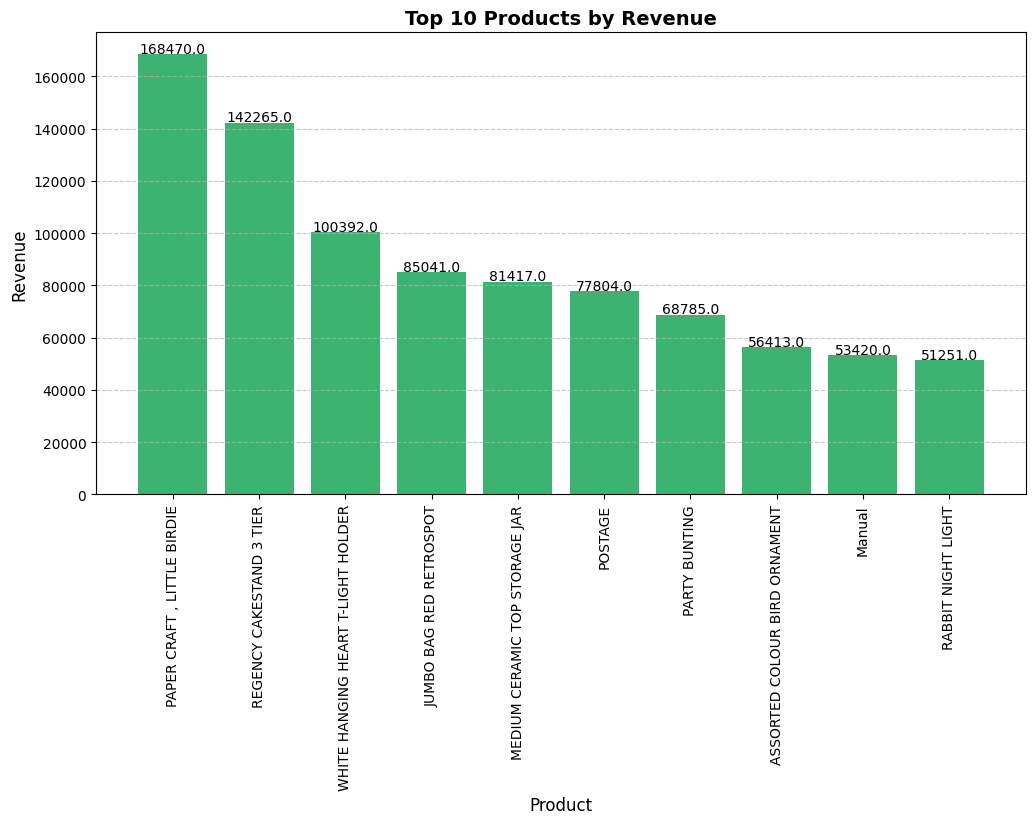

In [83]:
# Visualization
plt.figure(figsize=(12,6))
plt.bar(top_products_rev.index, top_products_rev.values, color='mediumseagreen')
plt.xticks(rotation=90)
plt.title('Top 10 Products by Revenue', fontsize=14, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels on top of bars
for i, v in enumerate(top_products_rev.values):
    plt.text(i, v + 500, str(round(v,0)), ha='center', fontsize=10)

plt.xlabel('Product', fontsize=12)
plt.ylabel('Revenue', fontsize=12)
plt.show()

In [ ]:
# STEP 3 : Top Customers

In [98]:
# Top 10 customers by quantity purchased
top_customers = df.groupby('CustomerID')['Quantity'].sum().sort_values(ascending=False).head(10)
top_customers

CustomerID
14646.0    196915
16446.0     80997
14911.0     80240
12415.0     77374
12346.0     74215
17450.0     69973
17511.0     64549
18102.0     64124
13694.0     63312
14298.0     58343
Name: Quantity, dtype: int64

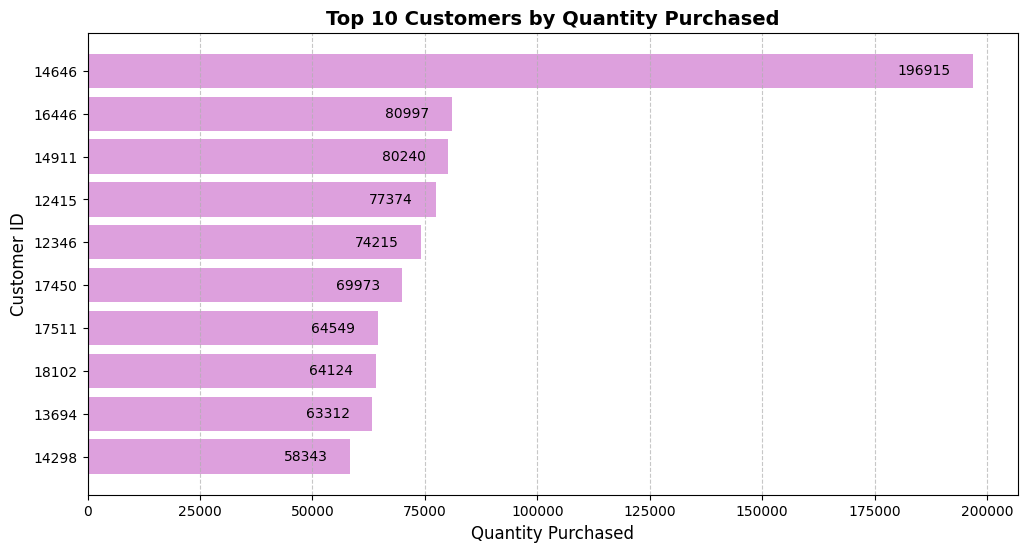

In [117]:
# Visualization
plt.figure(figsize=(12,6))
plt.barh(range(len(top_customers)), top_customers.values, color='plum')
plt.yticks(range(len(top_customers)), top_customers.index.astype(int))
plt.title('Top 10 Customers by Quantity Purchased', fontsize=14, fontweight='bold')
plt.xlabel('Quantity Purchased', fontsize=12)
plt.ylabel('Customer ID', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

for i, v in enumerate(top_customers.values):
    plt.text(v - 5000, i, str(v), va='center', ha='right', fontsize=10)

plt.gca().invert_yaxis()
plt.show()

In [ ]:
# STEP 4 : Top Countries by Quantity Sold

In [123]:
# Top 10 countries by quantity sold
top_countries_qty = df.groupby('Country')['Quantity'].sum().sort_values(ascending= False).head(10)
top_countries_qty


Country
United Kingdom    4241305
Netherlands        200361
EIRE               140133
Germany            119154
France             111428
Australia           83891
Sweden              36078
Switzerland         30082
Spain               27933
Japan               26016
Name: Quantity, dtype: int64

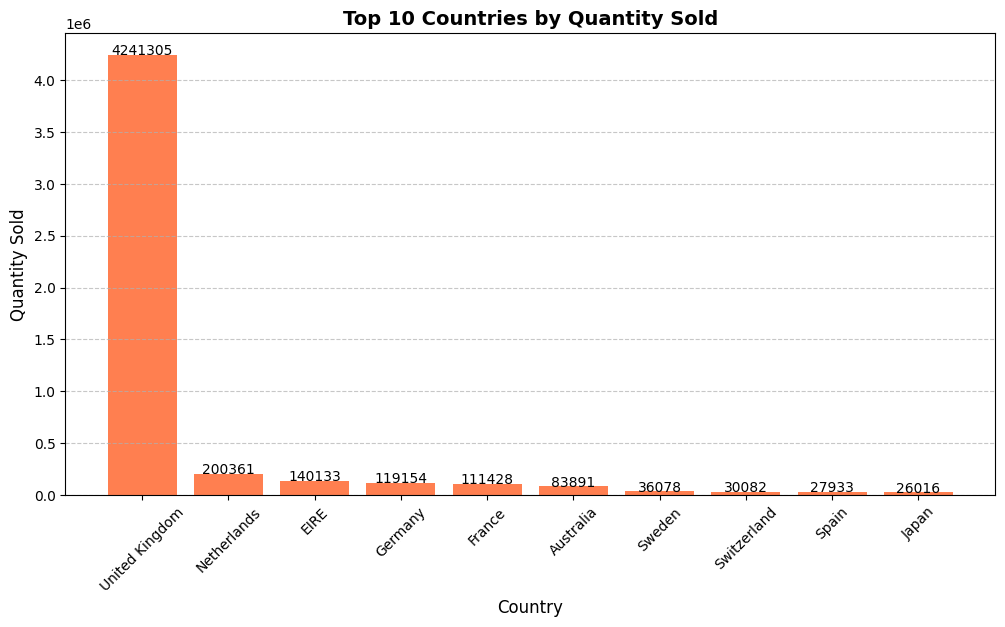

In [124]:
plt.figure(figsize=(12,6))
plt.bar(top_countries_qty.index, top_countries_qty.values, color='coral')
plt.xticks(rotation=45)
plt.title('Top 10 Countries by Quantity Sold', fontsize=14, fontweight='bold')
plt.xlabel('Country', fontsize=12)
plt.ylabel('Quantity Sold', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels
for i, v in enumerate(top_countries_qty.values):
   plt.text(i, v + 500, str(v), ha='center', fontsize=10)

plt.show()

In [ ]:
#STEP 5 : Top Countries by Revenue

In [125]:
# Top 10 countries by revenue
top_countries_rev = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)
top_countries_rev


Country
United Kingdom    7285024.644
Netherlands        285446.340
EIRE               265262.460
Germany            228678.400
France             208934.310
Australia          138453.810
Spain               61558.560
Switzerland         56443.950
Belgium             41196.340
Sweden              38367.830
Name: TotalPrice, dtype: float64

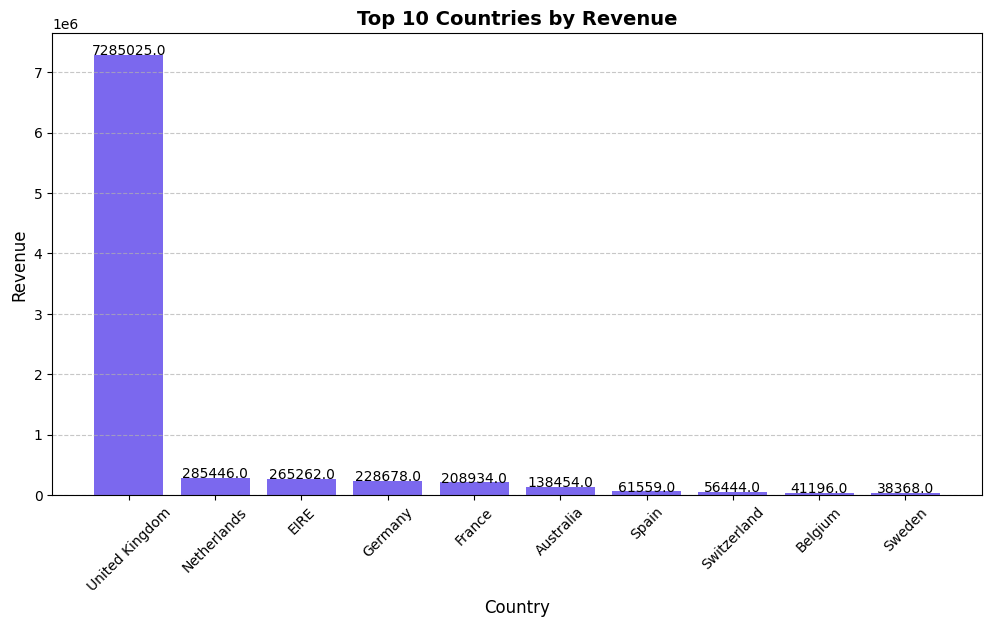

In [126]:
#Visualization
plt.figure(figsize=(12,6))
plt.bar(top_countries_rev.index, top_countries_rev.values, color='mediumslateblue')
plt.xticks(rotation=45)
plt.title('Top 10 Countries by Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Country', fontsize=12)
plt.ylabel('Revenue', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels
for i, v in enumerate(top_countries_rev.values):
    plt.text(i, v + 500, str(round(v,0)), ha='center', fontsize=10)

plt.show()